# Aplicando SVM (SVC) e GridSearchCV no dataset California Housing

Dataset: California Housing Prices. Cada linha é um quarteirão da Califórnia (censo de 1990)

Objetivo: SVC é um classificador, então fazemos a transformação em classes (preço mediano das casas/ median_house_value) nas faixas — baixo, médio e alto — modelo preve a faixa de preço a partir das características do dataset

### Import

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

### Carregamento e análise

In [77]:
df = pd.read_csv('housing.csv')
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


#### Valores N/A

In [79]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

#### Verificando dados categóricos - OneHot

In [80]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

#### Escala das variáveis
Ussnado o Standard Scaler para as colunas que tem escalas diferentes. Como o SVM trabalha com distâncias no plot, tem que normalizar.

In [81]:
df.describe().T[['mean','std','min','max']]

,mean,std,min,max
longitude,-119.569704,2.003532,-124.3500,-114.3100
latitude,35.631861,2.135952,32.5400,41.9500
housing_median_age,28.639486,12.585558,1.0000,52.0000
total_rooms,2635.763081,2181.615252,2.0000,39320.0000
total_bedrooms,537.870553,421.385070,1.0000,6445.0000
population,1425.476744,1132.462122,3.0000,35682.0000
households,499.539680,382.329753,1.0000,6082.0000
median_income,3.870671,1.899822,0.4999,15.0001
median_house_value,206855.816909,115395.615874,14999.0000,500001.0000


### Criação da variável alvo (classes) 
median_house_value em 3 faixas, mesmno número de amostras

faixa_preco
baixo    6884
alto     6880
medio    6876
Name: count, dtype: int64


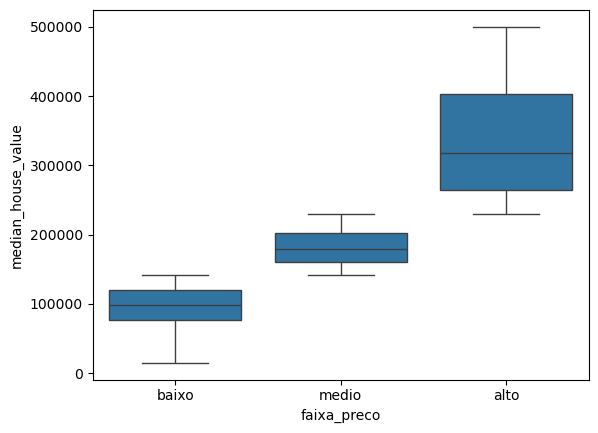

In [82]:
df['faixa_preco'] = pd.qcut(df['median_house_value'], q=3, labels=['baixo', 'medio', 'alto'])
print(df['faixa_preco'].value_counts())
sns.boxplot(data=df, x='faixa_preco', y='median_house_value')
plt.show()

### Separação de X e y
Remove o target e divide em treino e teste

In [83]:
X = df.drop(columns=['median_house_value', 'faixa_preco'])
y = df['faixa_preco']

colunas_numericas = X.select_dtypes(include='number').columns.tolist()
colunas_categoricas = ['ocean_proximity']
print('num:', colunas_numericas)
print('cat:', colunas_categoricas)

num: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
cat: ['ocean_proximity']


### Divisão em treino e teste
80% treino / 20% teste, com `stratify=y` para manter a proporção das classes.

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(16512, 9) (4128, 9)


### Pré-processamento - N/A, normalização e encode
ColumnTransformer dentro de um Pipeline. Tratamento só com os dados de treino depos é aplicado igualmente no teste e em cada fold do GridSearchCV.

Numéricas: strategy='median' preenche N/A com a mediana → StandardScaler normaliza
Categórica: OneHotEncoder transforma os textos da coluna ocean_proxitmity

In [85]:
preprocessamento = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), colunas_numericas),
    ('cat', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas),
])

pipeline = Pipeline([
    ('prep', preprocessamento),
    ('svc', SVC()),
])
pipeline

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ocean_proximity'])])),
                ('svc', SVC())])

### Modelo base (SVC sem ajuste)

In [86]:
pipeline.fit(X_train, y_train)
y_pred_base = pipeline.predict(X_test)
print(f'Acurácia SVC padrão: {accuracy_score(y_test, y_pred_base) * 100:.2f}%')

Acurácia SVC padrão: 75.85%


### GridSearchCV
GridSearchCV testa as combinações de hiperparâmetros com validação cruzada

C: penalidade por erro maior = mais justa aos dados de treino

kernel: formato da fronteira linear: dados lineares, rbf: dados n lineares

gamma: alcance de influência de cada ponto no kernel rbf.

In [87]:
parametros = [
    {'svc__kernel': ['linear'], 'svc__C': [0.1, 1, 10]},
    {'svc__kernel': ['rbf'], 'svc__C': [1, 10, 100], 'svc__gamma': ['scale', 0.1, 1]},
]

grid = GridSearchCV(pipeline, parametros, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print('Melhores parâmetros:', grid.best_params_)
print(f'Melhor acurácia na validação cruzada: {grid.best_score_ * 100:.2f}%')

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Melhores parâmetros: {'svc__C': 100, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Melhor acurácia na validação cruzada: 78.04%


In [88]:
resultados = pd.DataFrame(grid.cv_results_)[['params', 'mean_test_score', 'rank_test_score']]
resultados.sort_values('rank_test_score')

,params,mean_test_score,rank_test_score
9,"{'svc__C': 100, 'svc__gamma': 'scale', 'svc__k...",0.780402,1
10,"{'svc__C': 100, 'svc__gamma': 0.1, 'svc__kerne...",0.780402,2
6,"{'svc__C': 10, 'svc__gamma': 'scale', 'svc__ke...",0.771439,3
7,"{'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel...",0.770046,4
8,"{'svc__C': 10, 'svc__gamma': 1, 'svc__kernel':...",0.766170,5
5,"{'svc__C': 1, 'svc__gamma': 1, 'svc__kernel': ...",0.761931,6
3,"{'svc__C': 1, 'svc__gamma': 'scale', 'svc__ker...",0.757752,7
4,"{'svc__C': 1, 'svc__gamma': 0.1, 'svc__kernel'...",0.756480,8
11,"{'svc__C': 100, 'svc__gamma': 1, 'svc__kernel'...",0.735889,9
2,"{'svc__C': 10, 'svc__kernel': 'linear'}",0.729772,10


### Avaliação do melhor modelo no conjunto de teste

In [95]:
melhor_modelo = grid.best_estimator_
y_pred = melhor_modelo.predict(X_test)

print(f'Acc SVC base:       {accuracy_score(y_test, y_pred_base) * 100:.2f}%')
print(f'Acc SVC + GridSearch: {accuracy_score(y_test, y_pred) * 100:.2f}%\n')
print(classification_report(y_test, y_pred))

Acc SVC base:       75.85%
Acc SVC + GridSearch: 78.12%

              precision    recall  f1-score   support

        alto       0.84      0.80      0.82      1376
       baixo       0.82      0.84      0.83      1377
       medio       0.68      0.70      0.69      1375

    accuracy                           0.78      4128
   macro avg       0.78      0.78      0.78      4128
weighted avg       0.78      0.78      0.78      4128



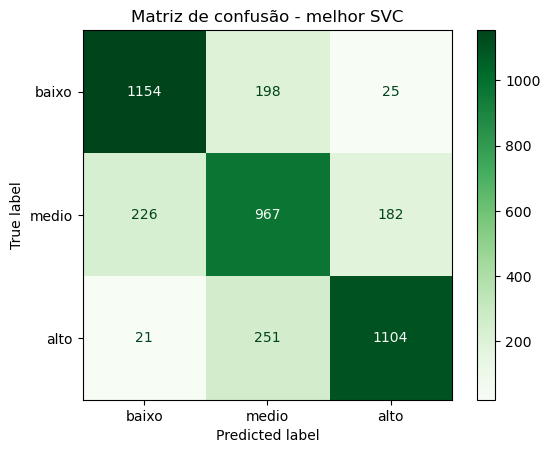

In [96]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=['baixo', 'medio', 'alto'], cmap='Greens')
plt.title('Matriz de confusão - melhor SVC')
plt.show()